In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/cadiyubu/Project_W7_CoffeeHealth/refs/heads/bibian2/data/raw/salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,MI,FT,Machine Learning Engineer,200200,USD,200200,US,0,US,M
1,2024,MI,FT,Machine Learning Engineer,186915,USD,186915,US,0,US,M
2,2024,MI,FT,Software Engineer,240240,USD,240240,US,0,US,M
3,2024,MI,FT,Software Engineer,221596,USD,221596,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,240240,USD,240240,US,0,US,M


In [3]:
#df.rename(columns={col : col.strip() for col in df.columns}, inplace = True)
#df.rename(columns={col : col.replace(" ", "_").lower() for col in df.columns}, inplace = True)

In [4]:
def df_info(df):
    print("\n    ---- df info ---")
    print(df.info())
    print("\n    ---- Empty Values ---")
    print(df.isna().sum())
    print("\n    ----- Dtypes -----")
    print(df.dtypes)
    print("\n    ---- Statistics ---")
    return df.describe()
df_info(df)


    ---- df info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29562 entries, 0 to 29561
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           29562 non-null  int64 
 1   experience_level    29562 non-null  object
 2   employment_type     29562 non-null  object
 3   job_title           29562 non-null  object
 4   salary              29562 non-null  int64 
 5   salary_currency     29562 non-null  object
 6   salary_in_usd       29562 non-null  int64 
 7   employee_residence  29562 non-null  object
 8   remote_ratio        29562 non-null  int64 
 9   company_location    29562 non-null  object
 10  company_size        29562 non-null  object
dtypes: int64(4), object(7)
memory usage: 2.5+ MB
None

    ---- Empty Values ---
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd      

,work_year,salary,salary_in_usd,remote_ratio
count,29562.000000,2.956200e+04,29562.000000,29562.000000
mean,2023.567282,1.641725e+05,156262.504499,25.260470
std,0.657533,2.593987e+05,70767.667632,43.200518
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2023.000000,1.065000e+05,106500.000000,0.000000
50%,2024.000000,1.463000e+05,146000.000000,0.000000
75%,2024.000000,1.980000e+05,196900.000000,50.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


In [5]:
region_map = {
    # North America
    'US': 'North_America', 'CA': 'North_America', 'MX': 'North_America',
    'PR': 'North_America', 'BS': 'North_America', 'HN': 'North_America',
    # Europe West
    'GB': 'Europe_West', 'DE': 'Europe_West', 'FR': 'Europe_West',
    'NL': 'Europe_West', 'IE': 'Europe_West', 'CH': 'Europe_West',
    'AT': 'Europe_West', 'BE': 'Europe_West', 'LU': 'Europe_West',
    'DK': 'Europe_West', 'SE': 'Europe_West', 'FI': 'Europe_West',
    'NO': 'Europe_West', 'PT': 'Europe_West', 'ES': 'Europe_West',
    'IT': 'Europe_West', 'GR': 'Europe_West', 'GI': 'Europe_West',
    # Europe East
    'PL': 'Europe_East', 'RO': 'Europe_East', 'CZ': 'Europe_East',
    'HU': 'Europe_East', 'SK': 'Europe_East', 'UA': 'Europe_East',
    'RS': 'Europe_East', 'HR': 'Europe_East', 'SI': 'Europe_East',
    'LT': 'Europe_East', 'LV': 'Europe_East', 'EE': 'Europe_East',
    'BA': 'Europe_East', 'MD': 'Europe_East', 'AD': 'Europe_East',
    # Asia Pacific
    'IN': 'Asia_Pacific', 'CN': 'Asia_Pacific', 'JP': 'Asia_Pacific',
    'KR': 'Asia_Pacific', 'SG': 'Asia_Pacific', 'AU': 'Asia_Pacific',
    'NZ': 'Asia_Pacific', 'HK': 'Asia_Pacific', 'TH': 'Asia_Pacific',
    'VN': 'Asia_Pacific', 'PH': 'Asia_Pacific', 'MY': 'Asia_Pacific',
    'ID': 'Asia_Pacific', 'PK': 'Asia_Pacific', 'IR': 'Asia_Pacific',
    # Middle East
    'AE': 'Middle_East', 'SA': 'Middle_East', 'QA': 'Middle_East',
    'IL': 'Middle_East', 'IQ': 'Middle_East', 'OM': 'Middle_East',
    'LB': 'Middle_East', 'AM': 'Middle_East',
    # Latin America
    'BR': 'Latin_America', 'AR': 'Latin_America', 'CL': 'Latin_America',
    'CO': 'Latin_America', 'VE': 'Latin_America', 'EC': 'Latin_America',
    # Africa
    'ZA': 'Africa', 'NG': 'Africa', 'KE': 'Africa', 'EG': 'Africa',
    'GH': 'Africa', 'DZ': 'Africa', 'CF': 'Africa', 'MU': 'Africa',
    # Other
    'MT': 'Other', 'AS': 'Other', 'RU': 'Other',
}

df['company_region'] = df['company_location'].map(region_map).fillna('Other')
df['residence_region'] = df['employee_residence'].map(region_map).fillna('Other')

Model 1 — predicts salary from company-related features (Diana).
Model 2 — predicts salary from experience level 

We are going to study two models, Diana m1 and Bibian m2:


m1 = 'job_title','company_size', 'salary_currency','company_location','residence_region'


m2 = 'job_title','employee_residence','experience_level', 'employment_type', 'salary_currency'

In [6]:
print("\nnumber of unique job titles ")
print(df.job_title.nunique())

print("\nnumber of unique employee residence region")
print(df.residence_region.nunique())

print("\nnumber of unique experience levels")
print(df.experience_level.nunique())

print("\nnumber of unique employment types")
print(df.employment_type.nunique())


number of unique job titles 
196

number of unique employee residence region
8

number of unique experience levels
4

number of unique employment types
4


### Employee residence

In [7]:
df['residence_region'].value_counts()

residence_region
North_America    27484
Europe_West       1508
Asia_Pacific       228
Europe_East        121
Latin_America       82
Africa              71
Other               47
Middle_East         21
Name: count, dtype: int64

We are keeping only data where employee_residence > 100

In [8]:
#residence_counts = df['employee_residence'].value_counts()

#more_than_100 = residence_counts[residence_counts >= 100].index

#df_f = df[df['employee_residence'].isin(more_than_100)].copy()

#display (df_f['employee_residence'].value_counts())
#display (df_f.shape)
#display (df.shape)

### job titles

In [9]:
df['job_title'].value_counts()

job_title
Data Scientist                   6450
Data Engineer                    5393
Data Analyst                     3813
Machine Learning Engineer        3209
Software Engineer                1513
                                 ... 
Applied Research Scientist          1
CRM Data Analyst                    1
Big Data Developer                  1
Quantitative Research Analyst       1
Analytics Engineering Manager       1
Name: count, Length: 196, dtype: int64

In [10]:
title_counts = df['job_title'].value_counts()

more_than_1000_jobs = title_counts[title_counts >= 150].index

df_f = df[df['job_title'].isin(more_than_1000_jobs)].copy()

display (df_f['job_title'].value_counts())
display (df_f.shape)
display (df.shape)


job_title
Data Scientist                    6450
Data Engineer                     5393
Data Analyst                      3813
Machine Learning Engineer         3209
Software Engineer                 1513
Research Scientist                1319
Applied Scientist                  771
Data Architect                     725
Analytics Engineer                 654
Research Engineer                  600
Business Intelligence Engineer     374
Business Intelligence Analyst      329
Data Manager                       318
AI Engineer                        253
Research Analyst                   229
Business Intelligence              222
Machine Learning Scientist         206
Data Specialist                    164
Name: count, dtype: int64

(26542, 13)

(29562, 13)

In [11]:
X=df_f[['job_title','residence_region','experience_level', 'employment_type', 'salary_in_usd']]
X.head()


,job_title,residence_region,experience_level,employment_type,salary_in_usd
0,Machine Learning Engineer,North_America,MI,FT,200200
1,Machine Learning Engineer,North_America,MI,FT,186915
2,Software Engineer,North_America,MI,FT,240240
3,Software Engineer,North_America,MI,FT,221596
4,Machine Learning Engineer,North_America,SE,FT,240240


In [12]:
# X.to_csv('m2_model_clean.csv', sep=',', index=False)

### salary by country

In [13]:
import scipy.stats as stats

group1 = X[X['residence_region'] == 'North_America']['salary_in_usd']
group2 = X[X['residence_region'] == 'Europe_West']['salary_in_usd']
group3 = X[X['residence_region'] == 'Asia_Pacific']['salary_in_usd']
group4 = X[X['residence_region'] == 'Europe_East']['salary_in_usd']
group5 = X[X['residence_region'] == 'Latin_America ']['salary_in_usd']

# ANOVA
f_stat, p_value = stats.f_oneway(group1, group2, group3, group4, group5)


print(f"Estadístico F: {f_stat:.4f}")
print(f"P-Value: {p_value:.16f}")

Estadístico F: nan
P-Value: nan


C:\Users\fotos\AppData\Local\Temp\ipykernel_14436\1236813768.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_oneway(group1, group2, group3, group4, group5)


### salary by job title

In [14]:
datas_group_job = X[X['job_title'] == 'Data Scientist']['salary_in_usd']
datae_group_job = X[X['job_title'] == 'Data Engineer']['salary_in_usd']
dataa_group_job = X[X['job_title'] == 'Data Analyst']['salary_in_usd']
datam_group_job = X[X['job_title'] == 'Machine Learning Engineer']['salary_in_usd']

# ANOVA one way
f_stat, p_value = stats.f_oneway(datas_group_job, datae_group_job, dataa_group_job, datam_group_job)


print(f"Estadístico F: {f_stat:.4f}")
print(f"P-Value: {p_value:.16f}")

Estadístico F: 1230.5721
P-Value: 0.0000000000000000


### salary by experience level

In [15]:
exp_en_group_exp = df_f[df_f['experience_level'] == 'EN']['salary_in_usd']
exp_ex_group_exp = df_f[df_f['experience_level'] == 'EX']['salary_in_usd']
exp_mi_group_exp = df_f[df_f['experience_level'] == 'MI']['salary_in_usd']
exp_se_group_exp = df_f[df_f['experience_level'] == 'SE']['salary_in_usd']

# ANOVA
f_stat, p_value = stats.f_oneway(exp_en_group_exp, exp_ex_group_exp, exp_mi_group_exp, exp_se_group_exp)


print(f"Estadístico F: {f_stat:.4f}")
print(f"P-Value: {p_value:.16f}")

Estadístico F: 928.3411
P-Value: 0.0000000000000000


In [16]:
from scipy.stats import f_oneway

In [17]:
cat_cols = X.select_dtypes(include="object").columns

results = {
    col: f_oneway(*X.groupby(col)["salary_in_usd"].apply(list))
    for col in cat_cols
}

[print(f"{col:25} F={f:8.1f}  p={p:.2e}") for col, (f, p) in results.items()]

job_title                 F=   324.8  p=0.00e+00
residence_region          F=   299.7  p=0.00e+00
experience_level          F=   928.3  p=0.00e+00
employment_type           F=    18.8  p=3.59e-12


[None, None, None, None]

In [18]:
#H0 rejected

In [19]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_f['salary_in_usd'],
                          groups=df_f['residence_region'],
                          alpha=0.05)
print(tukey)

              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
    group1        group2      meandiff   p-adj     lower        upper    reject
-------------------------------------------------------------------------------
       Africa  Asia_Pacific    2301.1458    1.0  -30461.6063   35063.898  False
       Africa   Europe_East  -23834.3828 0.4471  -59055.7768  11387.0111  False
       Africa   Europe_West    -786.6033    1.0   -29788.673  28215.4665  False
       Africa Latin_America  -15598.5396  0.916  -53350.1462  22153.0671  False
       Africa   Middle_East   10437.9283 0.9998   -57572.139  78447.9956  False
       Africa North_America   74966.0469    0.0   46517.9781 103414.1157   True
       Africa         Other  -32585.7872 0.3992  -79086.2711  13914.6966  False
 Asia_Pacific   Europe_East  -26135.5286 0.0552  -52569.1475    298.0902  False
 Asia_Pacific   Europe_West   -3087.7491 0.9994  -20388.3175  14212.8193  False
 Asia_Pacific Latin_America  -17899.6854

In [20]:
# cual es el mejor conjunto de columnas para el modelo que elijamos

### train test

In [21]:
#extracting features

In [22]:
def features_target_extract(df, drop_cols, target_col):
    df_model = df.drop(columns=drop_cols, errors='ignore')
    cols = df_model.columns
    target = df_model[target_col] if target_col in cols else None
    if target is None: print('No target column; returning features only')
    features = df_model.drop(columns=[c for c in [target_col] if c in cols])
    return df_model, features, target

In [23]:
X, features, target = features_target_extract(X, [], 'salary_in_usd')

In [24]:
display(X.head())
display(features.head())
display(target)

,job_title,residence_region,experience_level,employment_type,salary_in_usd
0,Machine Learning Engineer,North_America,MI,FT,200200
1,Machine Learning Engineer,North_America,MI,FT,186915
2,Software Engineer,North_America,MI,FT,240240
3,Software Engineer,North_America,MI,FT,221596
4,Machine Learning Engineer,North_America,SE,FT,240240


,job_title,residence_region,experience_level,employment_type
0,Machine Learning Engineer,North_America,MI,FT
1,Machine Learning Engineer,North_America,MI,FT
2,Software Engineer,North_America,MI,FT
3,Software Engineer,North_America,MI,FT
4,Machine Learning Engineer,North_America,SE,FT


0        200200
1        186915
2        240240
3        221596
4        240240
          ...  
29555     28369
29556    165000
29557    412000
29559    105000
29561     94665
Name: salary_in_usd, Length: 26542, dtype: int64

### train test split

In [25]:
X_train,X_test, y_train,y_test = train_test_split(features,target,test_size=0.2,random_state=0)
X_train.head()

,job_title,residence_region,experience_level,employment_type
20844,Data Analyst,North_America,SE,FT
19788,Data Scientist,North_America,SE,FT
15588,Data Scientist,North_America,MI,FT
28867,Data Scientist,North_America,SE,FT
12326,Research Scientist,North_America,MI,FT


In [26]:
# dummies for job_title	employee_residence	experience_level	employment_type

In [27]:
# from sklearn.preprocessing import OneHotEncoder

In [28]:
nonnum_cols = ['job_title','residence_region','experience_level', 'employment_type']

In [29]:
X_train = pd.get_dummies(X_train, columns=nonnum_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=nonnum_cols, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

In [31]:
X_train.shape

(21233, 30)

## Linear Regression

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

#evaluation
score_train = model.score(X_train_scaled, y_train)
score_test  = model.score(X_test_scaled,  y_test)

print(f"R² train: {score_train:.3f}")
print(f"R² test:  {score_test:.3f}")

R² train: 0.275
R² test:  0.274


In [43]:
y_pred_lr = model.predict(X_test_scaled)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
print(f"MAE:  {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")

MAE:  44094.05
RMSE: 59347.93


## KNN

In [33]:
# X_train_scaled 
# X_test_scaled

In [34]:
#def knn_modelling(train_df, test_df, y_train, y_test):
 #   knn = KNeighborsRegressor()
  #  knn.fit(train_df, y_train)
   # return f"The R2 of the model is {knn.score(test_df, y_test):.2f}"

In [44]:
knn = KNeighborsRegressor()
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
mae_knn  = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = root_mean_squared_error(y_test, y_pred_knn)

print(f"R2:   {knn.score(X_test_scaled, y_test):.4f}")
print(f"MAE:  {mae_knn:.2f}")
print(f"RMSE: {rmse_knn:.2f}")

R2:   0.2210
MAE:  46500.36
RMSE: 61712.13


## Bagging Regressor - Random Forests

In [36]:
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

#paremetrics

PARAMS = {
    'n_estimators': 100,
    'max_depth': 20,
    'random_state': 42
}

# training
model = BaggingRegressor(RandomForestRegressor(**PARAMS))
model.fit(X_train_scaled, y_train)

# predictions and metrics

y_pred = model.predict(X_test_scaled)

print(f"R2 Score: {model.score(X_test_scaled, y_test):.4f}")
print(f"MAE:      {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE:      {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE:     {root_mean_squared_error(y_test, y_pred):.2f}")

R2 Score: 0.2808
MAE:      44096.48
MSE:      3516340499.97
RMSE:     59298.74


### Random forest 

In [37]:
PARAMS = {
    'n_estimators': 100,
    'max_depth': 20,
    'random_state': 42
}

model = RandomForestRegressor(**PARAMS)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f"R2 Score: {model.score(X_test_scaled, y_test):.4f}")
print(f"MAE:      {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE:      {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE:     {root_mean_squared_error(y_test, y_pred):.2f}")

R2 Score: 0.2796
MAE:      44094.05
MSE:      3522176958.91
RMSE:     59347.93


## optuna optimization

In [41]:
import optuna
import time
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 50, 200),
        'max_depth':       trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features':    trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state':    42
    }
    
    rf = RandomForestRegressor(**params)
    scores = cross_val_score(rf, X_train_scaled, y_train, cv=3, scoring='r2')
    return scores.mean()

start = time.time()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) 
end = time.time()


print(f"\nTiempo: {end - start:.1f} segundos")
print(f"Mejor R2 en CV:    {study.best_value:.4f}")
print(f"Mejores parametros: {study.best_params}")

best_rf = RandomForestRegressor(**study.best_params, random_state=42)
best_rf.fit(X_train_scaled, y_train)

y_pred_opt = best_rf.predict(X_test_scaled)

print(f"\n--- Resultados en test ---")
print(f"R2:   {best_rf.score(X_test_scaled, y_test):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_opt):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_opt):.2f}")


Tiempo: 402.8 segundos
Mejor R2 en CV:    0.2770
Mejores parametros: {'n_estimators': 198, 'max_depth': 19, 'min_samples_split': 17, 'max_features': 'log2'}

--- Resultados en test ---
R2:   0.2806
MAE:  44050.37
RMSE: 59304.02


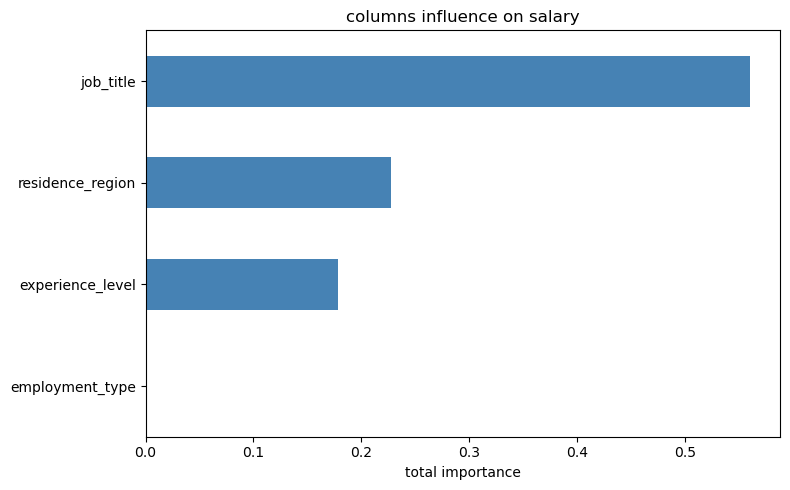

In [42]:
importances = model.feature_importances_
feature_names = X_train_scaled.columns

feat_imp = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15) 

orig_cols = ['experience_level', 'employment_type', 'job_title',
             'residence_region']

grouped = {}
for col in orig_cols:
    mask = feat_imp['feature'].str.startswith(col)
    grouped[col] = feat_imp.loc[mask, 'importance'].sum()

grouped_df = pd.Series(grouped).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
grouped_df.plot(kind='barh', color='steelblue')
plt.xlabel('total importance')
plt.title('columns influence on salary')
plt.tight_layout()
plt.show()

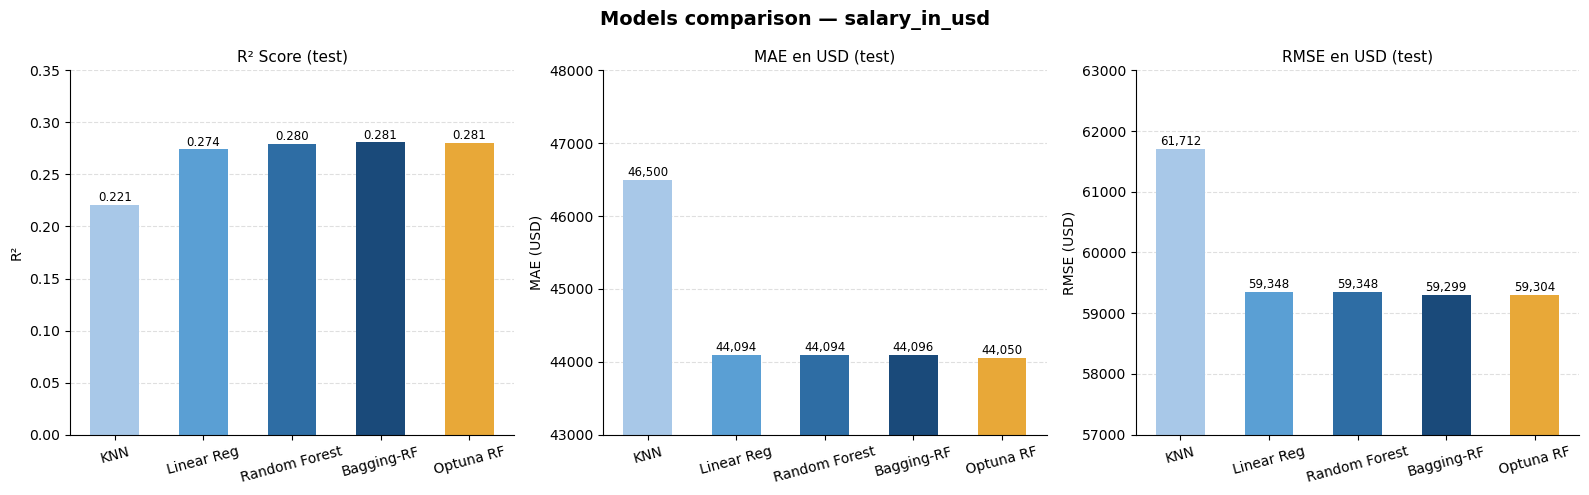

In [47]:
models    = ['KNN',    'Linear Reg', 'Random Forest', 'Bagging-RF', 'Optuna RF']
r2_scores = [0.2210,   0.274,        0.2796,          0.2808,       0.2806]
mae_scores = [46500,   44094,        44094,            44096,        44050]
rmse_scores = [61712,  59348,        59348,            59299,        59304]

colors = ['#a8c8e8', '#5a9fd4', '#2e6da4', '#1a4a7a', '#e8a838']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Models comparison — salary_in_usd', fontsize=14, fontweight='bold')

metricas = [
    (r2_scores,   'R² Score (test)',   'R²',       0,     0.35),
    (mae_scores,  'MAE en USD (test)', 'MAE (USD)', 43000, 48000),
    (rmse_scores, 'RMSE en USD (test)','RMSE (USD)',57000, 63000),
]

for ax, (vals, title, ylabel, ymin, ymax) in zip(axes, metricas):
    bars = ax.bar(models, vals, color=colors, width=0.55, zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        label = f'{val:.3f}' if isinstance(val, float) and val < 1 else f'{int(val):,}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (ymax-ymin)*0.01,
                label, ha='center', fontsize=8.5)

plt.tight_layout()
plt.show()

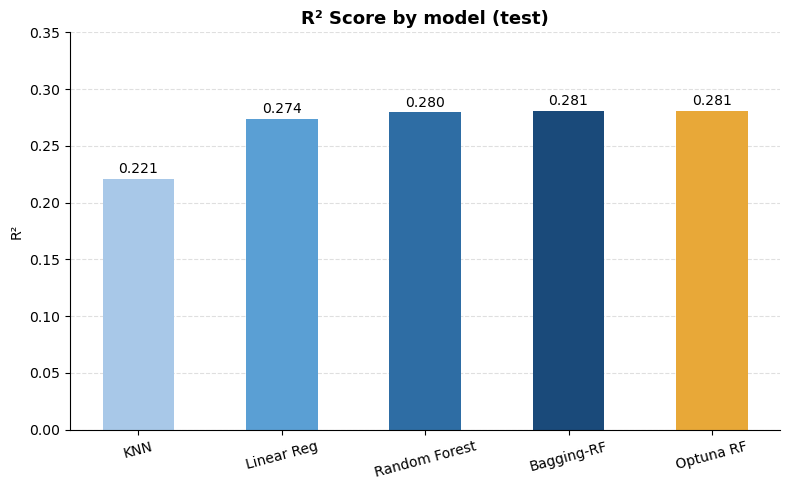

In [49]:
models    = ['KNN',  'Linear Reg', 'Random Forest', 'Bagging-RF', 'Optuna RF']
r2_scores = [0.2210, 0.274,        0.2796,          0.2808,       0.2806]
colors    = ['#a8c8e8', '#5a9fd4', '#2e6da4', '#1a4a7a', '#e8a838']

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(models, r2_scores, color=colors, width=0.5, zorder=2)

ax.set_title('R² Score by model (test)', fontsize=13, fontweight='bold')
ax.set_ylabel('R²')
ax.set_ylim(0, 0.35)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', rotation=15)

for bar, val in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

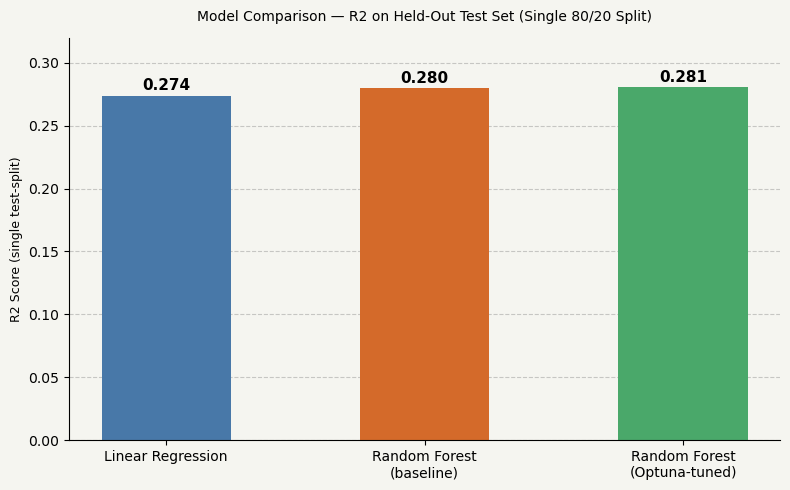

In [50]:
models    = ['Linear Regression', 'Random Forest\n(baseline)', 'Random Forest\n(Optuna-tuned)']
r2_scores = [0.274,               0.2796,                      0.2806]
colors    = ['#4878a8', '#d46a2a', '#4aa86a']  # azul, naranja, verde

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#f5f5f0')
ax.set_facecolor('#f5f5f0')

bars = ax.bar(models, r2_scores, color=colors, width=0.5, zorder=2)

ax.set_title('Model Comparison — R2 on Held-Out Test Set (Single 80/20 Split)',
             fontsize=10, pad=12)
ax.set_ylabel('R2 Score (single test-split)', fontsize=9)
ax.set_ylim(0, 0.32)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=1, color='gray')
ax.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

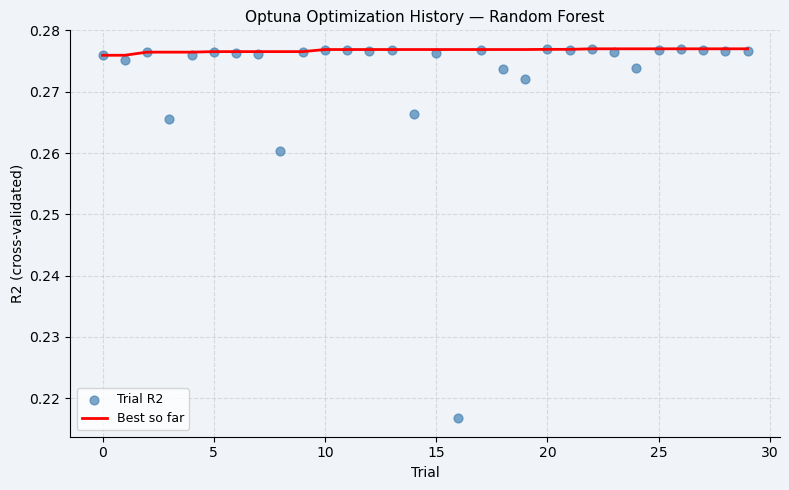

In [51]:
trial_r2   = [t.value for t in study.trials]
trial_nums = list(range(len(trial_r2)))

# la linea roja es el maximo acumulado hasta cada trial
best_so_far = [max(trial_r2[:i+1]) for i in range(len(trial_r2))]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#f0f4f8')
ax.set_facecolor('#f0f4f8')

# puntos de cada trial
ax.scatter(trial_nums, trial_r2, color='steelblue', alpha=0.7,
           s=40, zorder=2, label='Trial R2')

# linea del mejor acumulado
ax.plot(trial_nums, best_so_far, color='red', linewidth=2,
        zorder=3, label='Best so far')

ax.set_title('Optuna Optimization History — Random Forest', fontsize=11)
ax.set_xlabel('Trial')
ax.set_ylabel('R2 (cross-validated)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()